In [1]:
import pandas as pd
import numpy as np
import json
pd.set_option('display.max_columns', 500)

MARKET = "eth_cbbtc_usdc"

EVENTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_MARKET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"

df = pd.read_csv(f"{EVENTS_PATH}/{MARKET}.csv")
market_df = pd.read_csv(f"{HOURLY_MARKET_PATH}/{MARKET}.csv")

df.head(2)

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_1h,drawdown_1h,trend_1h,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h
0,0x55b1f9bfe77fa41b9f74b6949024ed40c61fda35554c...,MarketSupply,1726145495,0x29d4CDFee8F533af8529A9e1517b580E022874f7,1000000,0.999934,0,0.0,eth_cbbtc_usdc,2024-09-12 12:51:35,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,0.0,0.0,1.0,0.89,0.0,0.89,3,0.003503,0.0,0.013895,0.012367,NaN,0.999641,0.0,NaN,0.0,0.0,0.0,0.00005,NaN,0.88968,0.999641,0.0,0.0,0.0,position_open,False,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,0x55b1f9bfe77fa41b9f74b6949024ed40c61fda35554c...,MarketSupplyCollateral,1726145495,0x29d4CDFee8F533af8529A9e1517b580E022874f7,5000,2.903950,0,0.0,eth_cbbtc_usdc,2024-09-12 12:51:35,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,0.0,0.0,1.0,0.89,0.0,0.89,3,0.003503,0.0,0.013895,0.012367,NaN,0.999641,0.0,NaN,0.0,0.0,0.0,0.00005,NaN,0.88968,0.999641,0.0,0.0,0.0,position_open,False,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# TOKEN_NAME = df["collateral_asset_symbol"].unique()[0]
TOKEN_NAME = "PT-reUSD-25JUN2026"
yield_hist = pd.read_csv(f"/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/pt_yields/{TOKEN_NAME}.csv")
market_df = market_df.sort_values('timestamp')
yield_hist = yield_hist.sort_values('timestamp')
yield_hist = yield_hist[[
    "timestamp",
    "implied_apy",
    "underlying_apy",
    "base_apy",
]]
market_df = pd.merge_asof(market_df, yield_hist, on='timestamp', direction='nearest')
market_df.head(2)

# market_df['date'] = pd.to_datetime(market_df['datetime']).dt.date
# yield_hist['date'] = pd.to_datetime(yield_hist['date']).dt.date
# market_df = pd.merge(market_df, yield_hist[["date", "apy"]], on='date', how='left')


,timestamp,datetime,total_supply,total_borrow,utilization,borrow_rate,supply_rate,volatility_1h,drawdown_1h,volatility_6h,drawdown_6h,collateral_price,loan_asset_price,avg_health_factor,borrow_rate_rolling,supply_rate_rolling,asset_price,implied_apy,underlying_apy,base_apy
0,1726142400,2024-09-12 12:00:00,0.0,0.00,0.00,0.000000,0.000000,0,0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.16,0.157409,0.158622
1,1726146000,2024-09-12 13:00:00,1.0,0.89,0.89,0.013895,0.012367,0,0,0.0,0.0,0.0,0.999641,0.0,0.006948,0.006183,0.0,0.16,0.157409,0.158622


<Axes: >

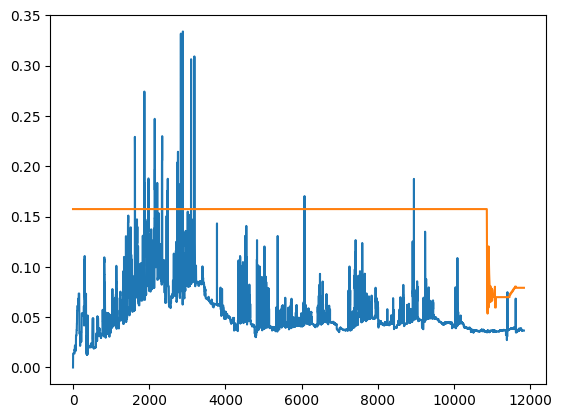

In [5]:
market_df["borrow_rate"].plot()
market_df["underlying_apy"].plot()